# Lab 04 

In [9]:
import subprocess, sys, os

# Instalujemy paczki jeśli brakuje (działa niezależnie od wybranego kernela)
_REQUIRED = ["numpy", "matplotlib", "gymnasium", "stable_baselines3", "sb3_contrib", "torch"]
_MISSING  = [p for p in _REQUIRED if __import__("importlib").util.find_spec(p) is None]
if _MISSING:
    print(f"Instaluję brakujące pakiety: {_MISSING} ...")
    subprocess.check_call([sys.executable, "-m", "pip", "install",
                           "gymnasium>=0.29", "numpy", "matplotlib",
                           "stable-baselines3>=2.0", "sb3-contrib>=2.0", "torch>=2.0"],
                          stdout=subprocess.DEVNULL)
    print("Instalacja zakończona.")

# ścieżka do lokalnych plików środowiska
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import gymnasium as gym

from custom_grid_taxi_env   import ENV_ID,     register_custom_grid_taxi
from custom_grid_taxi2p_env import ENV_ID_2P,  register_custom_grid_taxi2p

register_custom_grid_taxi()
register_custom_grid_taxi2p()

plt.rcParams.update({'figure.dpi': 120, 'font.family': 'monospace'})
print(f"Python: {sys.executable}")
print("OK — środowiska zarejestrowane")

Python: /Users/antonio/IOwAnalizie/inteligencja_obliczeniowa_w_analizie_danych/lab04/taxi/.venv/bin/python
OK — środowiska zarejestrowane


---
## 1. Środowisko v1 — jeden pasażer

Siatka 5×5, cztery stacje (R, G, Y, B). Taksówka odbiera pasażera z losowej stacji i dowozi do losowego celu. Akcje: ruch (N/S/E/W), pickup, dropoff — ściany blokują ruch po bokach.

In [10]:
# Podgląd mapy środowiska
env_v1 = gym.make(ENV_ID, render_mode='ansi')
obs, info = env_v1.reset(seed=7)
print(env_v1.render())
print(f'Przestrzeń obserwacji : {env_v1.observation_space}')
print(f'Przestrzeń akcji      : {env_v1.action_space}')
print(f'Obserwacja (stan)     : {obs}  (indeks 0–499)')
print(f'Maska akcji           : {info["action_mask"]}  (1=dozwolona)')
env_v1.close()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+


Przestrzeń obserwacji : Discrete(500)
Przestrzeń akcji      : Discrete(6)
Obserwacja (stan)     : 393  (indeks 0–499)
Maska akcji           : [1 1 0 1 0 0]  (1=dozwolona)


### Nagrody v1

| Zdarzenie | Nagroda |
|-----------|--------|
| każdy krok | −1 |
| dostawa do celu | **+20** |
| błędny pickup/dropoff | −10 |

---
## 2. Agent - MaskablePPO

Klasyczny PPO rozszerzony o **maski akcji** — w każdym kroku niedozwolone akcje (np. wjazd w ścianę, pickup gdy nikogo nie ma) są blokowane. Przyspiesza uczenie i eliminuje bezsensowne eksplorowanie.

In [11]:
# Jeden epizod losowej polityki (z maskowaniem) — co widzi agent krok po kroku
env = gym.make(ENV_ID, render_mode='ansi')
obs, info = env.reset(seed=42)
ACTIONS = {0:'↓S', 1:'↑N', 2:'→E', 3:'←W', 4:'PICK', 5:'DROP'}

total_r = 0
for step in range(1, 25):
    mask = np.asarray(info['action_mask'], dtype=np.int8)
    action = int(env.action_space.sample(mask=mask))
    obs, reward, terminated, truncated, info = env.step(action)
    total_r += reward
    if step <= 5 or terminated:
        print(f'krok {step:2d} | akcja={ACTIONS[action]:4s} | r={reward:+.0f} | suma={total_r:.0f}')
    if terminated:
        print('  → DOSTAWA! koniec epizodu')
        break

env.close()

krok  1 | akcja=←W   | r=-1 | suma=-1
krok  2 | akcja=→E   | r=-1 | suma=-2
krok  3 | akcja=←W   | r=-1 | suma=-3
krok  4 | akcja=→E   | r=-1 | suma=-4
krok  5 | akcja=←W   | r=-1 | suma=-5


---
## 3. Krzywa uczenia — v1 (1 pasażer)

Dane z `MaskableEvalCallback` — co 15 000 kroków agent był testowany na 15 epizodach.

Najlepsza śr. nagroda: 9.9  (przy 210k kroków)
Końcowa śr. długość epizodu: 12.9 kroków  (vs 200 na starcie)


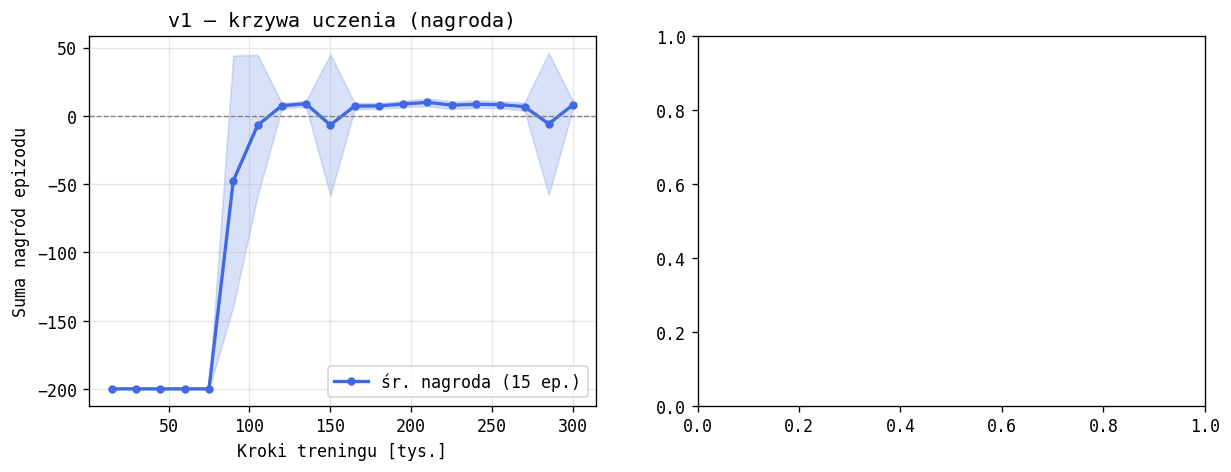

In [19]:
data_v1 = np.load('models/logs/evaluations.npz')
ts_v1   = data_v1['timesteps'] / 1_000          # tysiące kroków
rew_v1  = data_v1['results']                     # shape (n_checkpoints, n_eval_eps)
mean_v1 = rew_v1.mean(axis=1)
std_v1  = rew_v1.std(axis=1)
len_v1  = data_v1['ep_lengths'].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# --- nagroda ---
ax = axes[0]
ax.fill_between(ts_v1, mean_v1 - std_v1, mean_v1 + std_v1, alpha=0.2, color='royalblue')
ax.plot(ts_v1, mean_v1, 'o-', color='royalblue', lw=2, ms=4, label='śr. nagroda (15 ep.)')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Kroki treningu [tys.]')
ax.set_ylabel('Suma nagród epizodu')
ax.set_title('v1 — krzywa uczenia (nagroda)')
ax.legend()
ax.grid(alpha=0.3)



print(f'Najlepsza śr. nagroda: {mean_v1.max():.1f}  (przy {ts_v1[mean_v1.argmax()]:.0f}k kroków)')
print(f'Końcowa śr. długość epizodu: {len_v1[-1]:.1f} kroków  (vs 200 na starcie)')

---
## 4. Środowisko v2 — dwaj pasażerowie

Taxi wiezie jednego pasażera naraz. Musi odebrać i dostarczyć obu — w dowolnej kolejności. Trudniejszy problem: dłuższa sekwencja akcji, rzadszy sygnał nagrody.

In [13]:
env_v2 = gym.make(ENV_ID_2P, render_mode='ansi')
obs, info = env_v2.reset(seed=13)
print(env_v2.render())
print(f'Przestrzeń obserwacji : {env_v2.observation_space}  — wektor 12D')
print(f'Obserwacja            : {obs.round(2)}')
print()
print('Struktura wektora obserwacji:')
labels = ['taxi_r', 'taxi_c',
          'P1_status', 'P1_src_r', 'P1_src_c', 'P1_dst_r', 'P1_dst_c',
          'P2_status', 'P2_src_r', 'P2_src_c', 'P2_dst_r', 'P2_dst_c']
for name, val in zip(labels, obs):
    print(f'  {name:12s} = {val:.3f}')
env_v2.close()

+---------+
|R: | : :G|
| : | : : |
| : : : : |
| | : | : |
|Y| : |B: |
+---------+
P1(B→Y): czeka | P2(G→R): czeka

Przestrzeń obserwacji : Box(0.0, 1.0, (12,), float32)  — wektor 12D
Obserwacja            : [1.   0.   0.   1.   0.75 1.   0.   0.   0.   1.   0.   0.  ]

Struktura wektora obserwacji:
  taxi_r       = 1.000
  taxi_c       = 0.000
  P1_status    = 0.000
  P1_src_r     = 1.000
  P1_src_c     = 0.750
  P1_dst_r     = 1.000
  P1_dst_c     = 0.000
  P2_status    = 0.000
  P2_src_r     = 0.000
  P2_src_c     = 1.000
  P2_dst_r     = 0.000
  P2_dst_c     = 0.000


### Nagrody v2

| Zdarzenie | Nagroda |
|-----------|--------|
| każdy krok | −1 |
| udany pickup | **+5** |
| pierwsza dostawa | **+20** |
| druga dostawa (koniec!) | **+30** |
| błędna akcja | −10 |


---
## 5. Krzywa uczenia — v2 (2 pasażerowie)

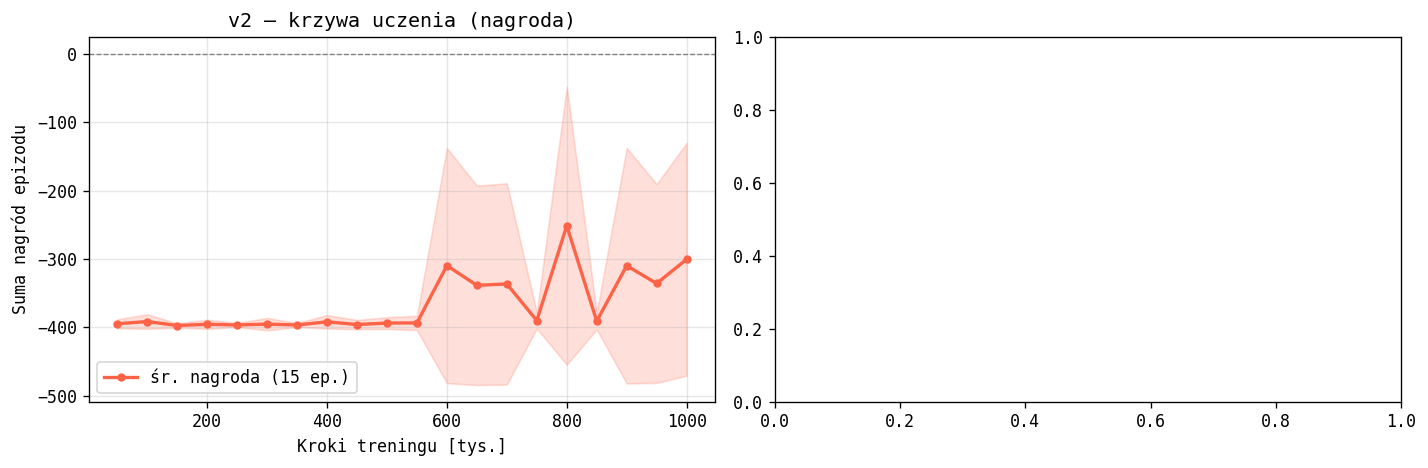

Najlepsza śr. nagroda: -251.4  (przy 800k kroków)
Końcowa śr. nagroda  : -300.5


In [20]:
data_v2 = np.load('models/logs_v2/evaluations.npz')
ts_v2   = data_v2['timesteps'] / 1_000
rew_v2  = data_v2['results']
mean_v2 = rew_v2.mean(axis=1)
std_v2  = rew_v2.std(axis=1)
len_v2  = data_v2['ep_lengths'].mean(axis=1)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ax = axes[0]
ax.fill_between(ts_v2, mean_v2 - std_v2, mean_v2 + std_v2, alpha=0.2, color='tomato')
ax.plot(ts_v2, mean_v2, 'o-', color='tomato', lw=2, ms=4, label='śr. nagroda (15 ep.)')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel('Kroki treningu [tys.]')
ax.set_ylabel('Suma nagród epizodu')
ax.set_title('v2 — krzywa uczenia (nagroda)')
ax.legend()
ax.grid(alpha=0.3)



plt.tight_layout()
plt.show()

best_idx = mean_v2.argmax()
print(f'Najlepsza śr. nagroda: {mean_v2.max():.1f}  (przy {ts_v2[best_idx]:.0f}k kroków)')
print(f'Końcowa śr. nagroda  : {mean_v2[-1]:.1f}')

---
## 6. Porównanie v1 vs v2

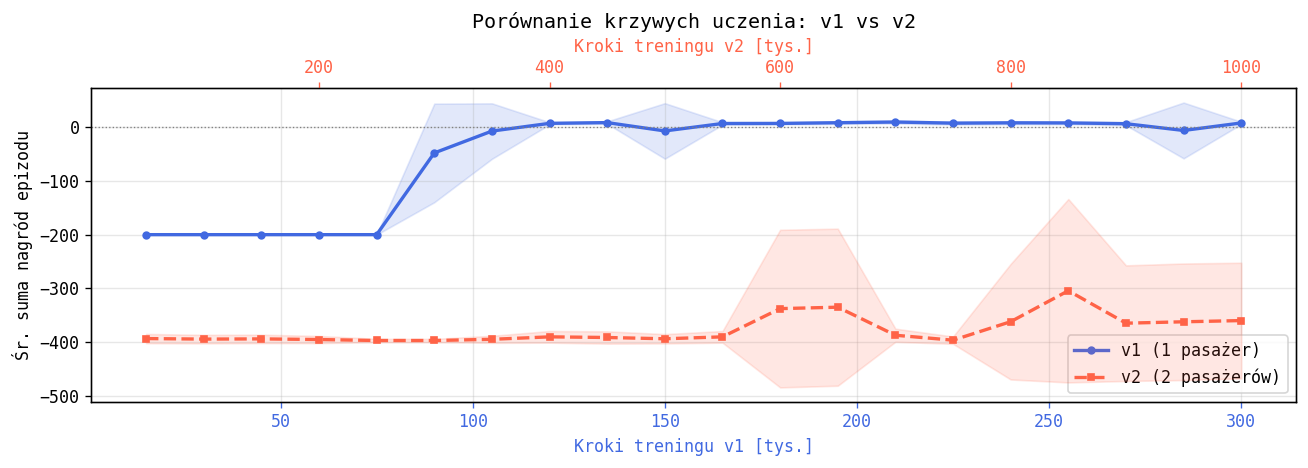

v1: szybka konwergencja (~75k kroków), problem prostszy (1 pasażer, obs. dyskretna)
v2: wolniejsza nauka, rzadszy sygnał nagrody, trudniejsza reprezentacja (Box 12D)


In [15]:
fig, ax = plt.subplots(figsize=(11, 4))

# normalizujemy timesteps do [0,1] żeby oba wykresy były porównywalne mimo różnej skali
ax.fill_between(ts_v1, mean_v1 - std_v1, mean_v1 + std_v1, alpha=0.15, color='royalblue')
ax.plot(ts_v1, mean_v1, 'o-', color='royalblue', lw=2, ms=4, label='v1 (1 pasażer)')

ax2 = ax.twiny()
ax2.fill_between(ts_v2, mean_v2 - std_v2, mean_v2 + std_v2, alpha=0.15, color='tomato')
ax2.plot(ts_v2, mean_v2, 's--', color='tomato', lw=2, ms=4, label='v2 (2 pasażerów)')
ax2.set_xlabel('Kroki treningu v2 [tys.]', color='tomato')
ax2.tick_params(axis='x', colors='tomato')

ax.set_xlabel('Kroki treningu v1 [tys.]', color='royalblue')
ax.tick_params(axis='x', colors='royalblue')
ax.set_ylabel('Śr. suma nagród epizodu')
ax.set_title('Porównanie krzywych uczenia: v1 vs v2')
ax.axhline(0, color='gray', lw=0.8, ls=':')
ax.grid(alpha=0.3)

lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.tight_layout()
plt.show()

print('v1: szybka konwergencja (~75k kroków), problem prostszy (1 pasażer, obs. dyskretna)')
print('v2: wolniejsza nauka, rzadszy sygnał nagrody, trudniejsza reprezentacja (Box 12D)')

---
## 7. Ewaluacja wytrenowanego agenta (w notebooku)



In [16]:
from pathlib import Path
from sb3_contrib import MaskablePPO
from sb3_contrib.common.wrappers import ActionMasker

def run_episode(env_id, model_path, seed=42, max_steps=400):
    env = ActionMasker(
        gym.make(env_id, render_mode='ansi'),
        lambda e: e.unwrapped.action_masks()
    )
    model = MaskablePPO.load(model_path)
    obs, _ = env.reset(seed=seed)
    ACTIONS = {0:'↓S', 1:'↑N', 2:'→E', 3:'←W', 4:'PICK', 5:'DROP'}
    total_r, steps = 0, 0
    for step in range(1, max_steps + 1):
        action, _ = model.predict(obs, action_masks=env.action_masks(), deterministic=True)
        obs, reward, terminated, truncated, _ = env.step(int(action))
        total_r += reward
        steps = step
        if reward > 1:
            print(f'  krok {step:3d}: {ACTIONS[int(action)]:4s}  nagroda={reward:+.0f}  suma={total_r:.0f}')
        if terminated or truncated:
            break
    env.close()
    return total_r, steps, terminated

V1_MODEL = Path('models/v1/best_model.zip')
V2_MODEL = Path('models/v2/best_model.zip')

print('=== v1 ===')
r, s, ok = run_episode(ENV_ID, V1_MODEL, seed=7)
print(f'  wynik: {r:.0f} nagród | {s} kroków | sukces={ok}\n')

if V2_MODEL.exists():
    print('=== v2 (2 pasażerowie) ===')
    r2, s2, ok2 = run_episode(ENV_ID_2P, V2_MODEL, seed=7)
    print(f'  wynik: {r2:.0f} nagród | {s2} kroków | sukces={ok2}')
else:
    print('v2: brak modelu — uruchom najpierw: python train.py --env v2')

=== v1 ===
  krok   9: DROP  nagroda=+20  suma=12
  wynik: 12 nagród | 9 kroków | sukces=True

=== v2 (2 pasażerowie) ===
  wynik: -400 nagród | 400 kroków | sukces=False
